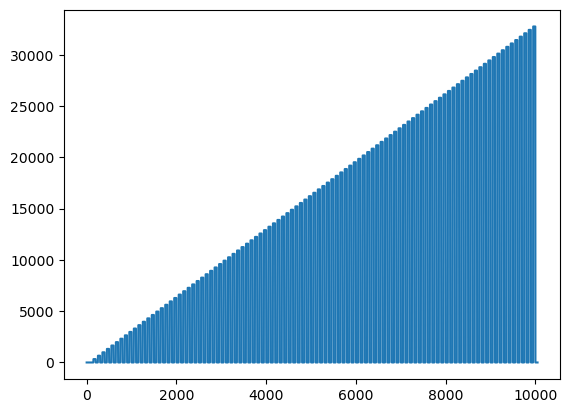

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os 

#AW Generator for ramped pulse-train

class wf_settings:
    
    def __init__(self,startV,endV,v_steps,duty):
        self.startV = startV
        self.endV = endV
        self.v_steps = v_steps
        self.duty = duty
        self.on = self.duty
        self.off = 100-self.duty
        self.arry = None
    
    def voltages(self):
        voltages = np.linspace(self.startV,self.endV,self.v_steps)
        voltages = np.float32(voltages*32767)
        return voltages

    def wf_generator(self):
        self.arry = np.empty(0)
        for x in self.voltages():
            self.arry = np.append(self.arry,np.full(self.off,0))
            self.arry = np.append(self.arry,np.full(self.on,x))

            if x == self.voltages()[-1]:
                self.arry = np.append(self.arry,np.full(self.off,0))
        plt.plot(self.arry)
        df = pd.DataFrame(self.arry)
        df.to_csv(self.get_path(),header=False, index=False)

    def get_path(self):
        cwd = os.getcwd()
        path = cwd + '\\AWs\\AW_{}Vto{}V_duty{}%_vsteps{}.csv'.format(self.startV,self.endV,self.duty,self.v_steps)
        return path
    
    def get_xmidpeak(self):
        stagger = self.off + self.on/2
        xmid = np.linspace(stagger,len(self.arry)-stagger,self.v_steps)
        return xmid
    
wf = wf_settings(0,1,100,50)
wf.wf_generator()

In [2]:
#pyvisa.write(":MMEMory:DOWNload:FNAMe <filename>") #for creating new file in internal memory
#MMEM:DOWN:FNAM"INT:\Myfile" example of file creation

import pyvisa
import csv
import time

# Connect to the instrument
rm = pyvisa.ResourceManager()
awg = rm.open_resource('USB0::0x0957::0x2C07::MY62003942::INSTR')  # Replace with your instrument's address

#path = 'C:\\Users\\pmlbl\\OneDrive\\Documents\\PythonScripts\\AutoScripts\\TTC_PhaseSweep_v2\\AW_{}to{}_duty{}%.csv'.format(wf.startV,wf.endV,wf.duty)
# Load the waveform from the CSV file
with open(wf.get_path(), 'r') as f:
    reader = csv.reader(f)
    waveform_data = [float(row[0]) for row in reader]
awg.write("*CLS")
awg.write("*RST")
#waveform_data = [ 32767, 24576, 16384, 8192, 0, -8192, -16384, -24576, - 32767]
# Send the waveform data to the instrument
awg.write(':SOURce1:DATA:VOLatile:CLEar')  # Clear the volatile memory
awg.write(':SOURce1:DATA:ARB:DAC {}, {}'.format('myarbx', ','.join(map(str, waveform_data))))
awg.write("SOURce1:FUNCtion:ARBitrary myarbx")
#awg.write(':SOURce1:DATA:ARB:DAC {}, {}'.format(len(waveform_data), ','.join(map(str, waveform_data))))

# # # Set the waveform as the output
awg.write(':SOURce1:FUNCtion ARB')
awg.write(':SOURce1:FUNCtion:ARB:SRATe 1e4')
awg.write(':SOURCE1:VOLTage 0.5')
# awg.write(':SOURce1:BURSt:MODE TRIGgered')
# awg.write(':SOURce1:BURSt:NCYCles 1')
# awg.write(':TRIGger:SOURce BUS')
# awg.write(':BURSt:STATe ON')
awg.write(':OUTPut1 ON')  # Turn on the output
#awg.write("*TRG")

#awg.write(':SOURce1:BURSt:INTernal:PERiod {} '.format())
#awg.write(':OUTPut1 ON')  # Turn on the output
# time.sleep(5)
# awg.write(':OUTPut1 OFF')  # Turn on the output

13

In [ ]:
# Explanation:
# 1. Import Libraries:
# visa: For communicating with instruments using the VISA standard.
# csv: For reading data from CSV files.
# 2. Connect to the Instrument:
# Replace 'USB0::0x0957::0x1796::MY52450000::0::INSTR' with the actual VISA address of your Agilent 33500B.
# 3. Load Waveform Data:
# Open the CSV file containing the waveform data.
# Read the data into a list.
# Convert the values to floats.
# 4. Send Waveform to Instrument:
# Clear the volatile memory of the instrument.
# Use the :SOURce1:DATA:ARB:DAC command to send the waveform data to the instrument.
# 5. Configure Output:
# Select the arbitrary waveform as the output function.
# Set the voltage unit and level.
# Turn on the output.
# Important Considerations:
# File Format: Ensure your CSV file contains a single column of data points representing the waveform.
# Voltage Range: Make sure the waveform data is within the voltage range of the instrument.
# Instrument Settings: Adjust the frequency, offset, and other settings as needed.

In [68]:
':SOURce1:DATA:ARB:DAC {}, {}'.format('myarb', ','.join(map(str, waveform_data)))

':SOURce1:DATA:ARB:DAC myarb, 0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158082962036,0.5263158

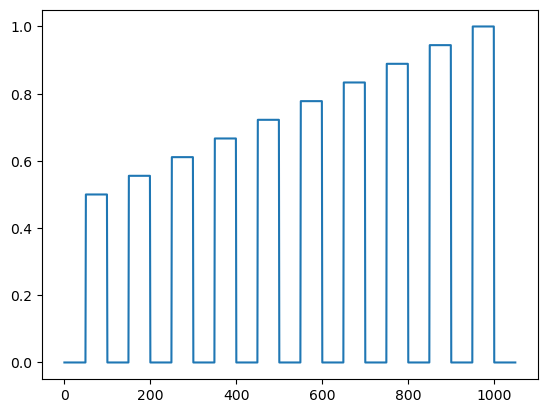

In [127]:
plt.plot(waveform_data)